<a href="https://colab.research.google.com/github/veernaik/Data_Science_16014324004_TY/blob/main/Data_Science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

Imported core libraries for data handling (numpy, pandas) and visualization (matplotlib, seaborn).


In [ ]:
from google.colab import files

uploaded = files.upload()

Saving weatherAUS.csv to weatherAUS (1).csv


This code is used for uploading the dataset in colab.

In [ ]:
df = pd.read_csv("weatherAUS.csv")

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


Dataset contains daily weather records for Australian locations. Some columns
like Evaporation and Sunshine already show NaN values, indicating missing data.

In [ ]:
df.shape

(145460, 23)

Dataset has 145,460 rows and 23 columns — a large dataset requiring proper preprocessing.

In [ ]:
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='object')

23 features covering date, location, temperature, rainfall, wind, humidity, pressure, and cloud cover, with RainTomorrow as the likely target variable.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 23 columns):
 #   Column         Non-Null Count   Dtype  
---  ------         --------------   -----  
 0   Date           145460 non-null  object 
 1   Location       145460 non-null  object 
 2   MinTemp        143975 non-null  float64
 3   MaxTemp        144199 non-null  float64
 4   Rainfall       142199 non-null  float64
 5   Evaporation    82670 non-null   float64
 6   Sunshine       75625 non-null   float64
 7   WindGustDir    135134 non-null  object 
 8   WindGustSpeed  135197 non-null  float64
 9   WindDir9am     134894 non-null  object 
 10  WindDir3pm     141232 non-null  object 
 11  WindSpeed9am   143693 non-null  float64
 12  WindSpeed3pm   142398 non-null  float64
 13  Humidity9am    142806 non-null  float64
 14  Humidity3pm    140953 non-null  float64
 15  Pressure9am    130395 non-null  float64
 16  Pressure3pm    130432 non-null  float64
 17  Cloud9am       89572 non-null

Non-uniform missingness across columns — Evaporation and Sunshine have far fewer non-null entries than other columns, meaning these features are sparsely recorded.


In [ ]:
df.describe()

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm
count,143975.000000,144199.000000,142199.000000,82670.000000,75625.000000,135197.000000,143693.000000,142398.000000,142806.000000,140953.000000,130395.00000,130432.000000,89572.000000,86102.000000,143693.000000,141851.00000
mean,12.194034,23.221348,2.360918,5.468232,7.611178,40.035230,14.043426,18.662657,68.880831,51.539116,1017.64994,1015.255889,4.447461,4.509930,16.990631,21.68339
std,6.398495,7.119049,8.478060,4.193704,3.785483,13.607062,8.915375,8.809800,19.029164,20.795902,7.10653,7.037414,2.887159,2.720357,6.488753,6.93665
min,-8.500000,-4.800000,0.000000,0.000000,0.000000,6.000000,0.000000,0.000000,0.000000,0.000000,980.50000,977.100000,0.000000,0.000000,-7.200000,-5.40000
25%,7.600000,17.900000,0.000000,2.600000,4.800000,31.000000,7.000000,13.000000,57.000000,37.000000,1012.90000,1010.400000,1.000000,2.000000,12.300000,16.60000
50%,12.000000,22.600000,0.000000,4.800000,8.400000,39.000000,13.000000,19.000000,70.000000,52.000000,1017.60000,1015.200000,5.000000,5.000000,16.700000,21.10000
75%,16.900000,28.200000,0.800000,7.400000,10.600000,48.000000,19.000000,24.000000,83.000000,66.000000,1022.40000,1020.000000,7.000000,7.000000,21.600000,26.40000
max,33.900000,48.100000,371.000000,145.000000,14.500000,135.000000,130.000000,87.000000,100.000000,100.000000,1041.00000,1039.600000,9.000000,9.000000,40.200000,46.70000


Temperatures look reasonable (MinTemp mean 12°C, MaxTemp mean 23°C). Rainfall is heavily right-skewed mean is low (2.36) but extreme values exist, suggesting outliers.


In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,1485
MaxTemp,1261
Rainfall,3261
Evaporation,62790
Sunshine,69835
WindGustDir,10326
WindGustSpeed,10263
WindDir9am,10566


Evaporation, Sunshine, Cloud9am, Cloud3pm, and Pressure9am/3pm have the highest missing counts — likely due to instruments not recording at every station.

In [ ]:
df.isnull().sum().sum()

np.int64(343248)

Total of 343,248 missing values across the dataset significant, justifying imputation.

In [ ]:
num_cols = df.select_dtypes(include=np.number).columns

df[num_cols] = df[num_cols].fillna(
    df[num_cols].mean()
)

In [ ]:
cat_cols = df.select_dtypes(include='object').columns

df[cat_cols] = df[cat_cols].fillna(
    df[cat_cols].mode().iloc[0]
)

Filled numeric columns with mean and categorical columns with mode. Simple approach, but may mask real regional variation (e.g., Evaporation/Sunshine averaged across all locations rather than by climate zone).

In [ ]:
df.isnull().sum()

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0


All columns now show 0 missing values imputation successful, dataset is complete.

In [ ]:
df.sort_values(
    by="MaxTemp",
    ascending=False
).head(5)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
106316,2011-01-25,Woomera,25.1,48.1,0.0,22.400000,12.800000,WSW,85.0,NNE,...,21.0,7.0,1003.40000,1000.400000,3.000000,2.00000,33.2,46.1,No,No
13806,2014-01-03,Moree,28.3,47.3,0.0,16.000000,12.000000,WSW,61.0,N,...,36.0,5.0,1001.90000,995.900000,1.000000,6.00000,33.4,45.8,No,No
14942,2017-02-12,Moree,27.8,47.3,0.0,5.468232,7.611178,SSW,67.0,NNE,...,30.0,10.0,1003.90000,998.100000,7.000000,1.00000,32.9,46.7,No,No
30041,2017-02-11,Richmond,22.3,47.0,0.0,5.468232,7.611178,SW,41.0,NE,...,84.0,18.0,1008.00000,1001.300000,4.000000,4.50993,25.8,44.7,No,No
27032,2017-02-11,Penrith,23.3,46.9,0.0,5.468232,7.611178,W,50.0,N,...,85.0,14.0,1017.64994,1015.255889,4.447461,4.50993,25.3,46.2,No,No


Hottest days (up to 48.1°C) occurred in inland locations like Woomera and Moree consistent with Australia's arid interior climate.

In [ ]:
df.sort_values(
    by="Rainfall",
    ascending=False
).head(8)

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
9368,2009-11-07,CoffsHarbour,17.400000,23.1,371.0,5.468232,3.500000,W,40.03523,SW,...,93.0,81.0,1026.60000,1025.900000,8.0,5.0,18.6,22.0,Yes,Yes
140071,2011-02-16,Darwin,22.100000,25.6,367.6,5.468232,0.000000,WSW,83.00000,SSE,...,98.0,98.0,996.30000,996.000000,8.0,8.0,24.3,23.5,Yes,Yes
87242,2009-01-12,Cairns,22.300000,27.4,278.4,5.468232,0.000000,NW,59.00000,SSE,...,96.0,98.0,1003.50000,999.600000,8.0,8.0,24.7,25.3,Yes,Yes
87995,2011-02-04,Cairns,22.900000,29.9,268.6,5.468232,2.000000,ENE,37.00000,ENE,...,82.0,84.0,1011.10000,1009.300000,6.0,8.0,29.8,28.0,Yes,Yes
89371,2015-02-08,Cairns,23.800000,31.0,247.2,5.468232,2.000000,E,44.00000,SSE,...,100.0,74.0,1014.20000,1011.400000,8.0,8.0,25.3,30.0,Yes,Yes
17321,2015-04-23,Newcastle,12.194034,21.7,240.0,5.468232,7.611178,W,40.03523,NW,...,72.0,62.0,1017.64994,1015.255889,6.0,6.0,17.5,21.0,Yes,No
93344,2009-02-03,Townsville,22.800000,25.4,236.8,5.468232,0.000000,ESE,48.00000,ESE,...,98.0,95.0,1003.80000,1000.600000,8.0,8.0,23.8,25.0,Yes,Yes
42010,2016-01-06,Williamtown,18.500000,19.9,225.0,5.468232,0.000000,S,80.00000,SSW,...,95.0,90.0,1008.50000,1008.800000,8.0,8.0,19.2,19.4,Yes,Yes


Heaviest rainfall (up to 371mm) occurred in tropical/coastal locations like Coffs Harbour, Darwin, and Cairns — matches Australia's monsoonal climate zones.

In [ ]:
df["RainTomorrow"].value_counts()

,count
RainTomorrow,
No,113583
Yes,31877


Class imbalance present "No" (113,583) far outweighs "Yes" (31,877), roughly 78/22 split. Will need to account for this in any classification model (e.g., class weights, resampling).

In [ ]:
df["Location"].value_counts().head(10)

,count
Location,
Canberra,3436
Sydney,3344
Adelaide,3193
Darwin,3193
Hobart,3193
Perth,3193
Melbourne,3193
Brisbane,3193
Albury,3040


Most locations have 3,000–3,400 records each fairly balanced station coverage, with Canberra having the most.

In [ ]:
df.sort_values(
    "Humidity3pm",
    ascending=False
).head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
144702,2015-05-30,Uluru,14.9,16.8,0.6,5.468232,7.611178,S,26.0,SSW,...,98.0,100.0,1022.9,1019.1,8.000000,8.00000,15.2,15.4,No,Yes
145278,2016-12-26,Uluru,22.1,27.4,83.8,5.468232,7.611178,ENE,72.0,N,...,100.0,100.0,994.6,989.2,8.000000,8.00000,22.2,24.2,Yes,Yes
145045,2016-05-07,Uluru,16.6,21.6,11.4,5.468232,7.611178,N,37.0,NE,...,100.0,100.0,1011.3,1006.4,8.000000,8.00000,16.7,19.9,Yes,Yes
55308,2009-06-25,Ballarat,0.2,9.1,0.0,5.468232,7.611178,NNE,26.0,NNE,...,100.0,100.0,1013.9,1011.0,8.000000,7.00000,5.7,8.1,No,No
143962,2013-05-20,Uluru,13.6,20.3,0.0,5.468232,7.611178,NE,33.0,ENE,...,69.0,100.0,1014.2,1011.6,4.447461,4.50993,17.6,17.8,No,Yes


High-humidity readings cluster around Uluru and Ballarat on specific dates useful signal for spotting rain-prone conditions.

In [ ]:
df.sort_index(axis=1).head()

,Cloud3pm,Cloud9am,Date,Evaporation,Humidity3pm,Humidity9am,Location,MaxTemp,MinTemp,Pressure3pm,...,Rainfall,Sunshine,Temp3pm,Temp9am,WindDir3pm,WindDir9am,WindGustDir,WindGustSpeed,WindSpeed3pm,WindSpeed9am
0,4.50993,8.000000,2008-12-01,5.468232,22.0,71.0,Albury,22.9,13.4,1007.1,...,0.6,7.611178,21.8,16.9,WNW,W,W,44.0,24.0,20.0
1,4.50993,4.447461,2008-12-02,5.468232,25.0,44.0,Albury,25.1,7.4,1007.8,...,0.0,7.611178,24.3,17.2,WSW,NNW,WNW,44.0,22.0,4.0
2,2.00000,4.447461,2008-12-03,5.468232,30.0,38.0,Albury,25.7,12.9,1008.7,...,0.0,7.611178,23.2,21.0,WSW,W,WSW,46.0,26.0,19.0
3,4.50993,4.447461,2008-12-04,5.468232,16.0,45.0,Albury,28.0,9.2,1012.8,...,0.0,7.611178,26.5,18.1,E,SE,NE,24.0,9.0,11.0
4,8.00000,7.000000,2008-12-05,5.468232,33.0,82.0,Albury,32.3,17.5,1006.0,...,1.0,7.611178,29.7,17.8,NW,ENE,W,41.0,20.0,7.0


Reorders columns alphabetically for readability no analytical insight here.

In [ ]:
df[
(df["MaxTemp"]>35) &
(df["Humidity3pm"]<40)
][["Location","MaxTemp","Humidity3pm"]].head()

,Location,MaxTemp,Humidity3pm
35,Albury,35.8,9.0
36,Albury,37.9,8.0
37,Albury,38.9,12.0
43,Albury,37.7,19.0
44,Albury,43.0,8.0


Confirms hot, low-humidity days exist in the data these conditions are typically associated with bushfire risk.

In [ ]:
df[
(df["Rainfall"]>20) &
(df["WindSpeed3pm"]>30)
][["Location","Rainfall","WindSpeed3pm"]].head()

,Location,Rainfall,WindSpeed3pm
146,Albury,21.0,31.0
356,Albury,25.8,46.0
462,Albury,66.0,37.0
2087,Albury,24.4,33.0
2744,Albury,33.6,31.0


Identifies days with both heavy rainfall (>20mm) and strong winds (>30 km/h)
likely storm events worth flagging separately.

In [ ]:
df[
(df["Pressure9am"]<1005) &
(df["Humidity9am"]>80)
][["Location","Pressure9am","Humidity9am"]].head()

,Location,Pressure9am,Humidity9am
145,Albury,1004.8,83.0
271,Albury,1002.6,81.0
296,Albury,997.8,82.0
317,Albury,1000.5,88.0
356,Albury,1003.7,98.0


Days with pressure 1005 hPa and humidity 80% classic precursors to rain, could be engineered into a "storm likelihood" feature.

In [ ]:
df["MaxTemp"].max()

48.1

Max temperature is 48.1°C

> Add blockquote



In [ ]:
df["MinTemp"].min()

-8.5

Min temperature is -8.5°C

In [ ]:
df["Rainfall"].max()

371.0

Max rainfall is 371mm

In [ ]:
df.groupby("Location")["MaxTemp"].mean()

,MaxTemp
Location,
Adelaide,22.899237
Albany,20.126958
Albury,22.642972
AliceSprings,29.244455
BadgerysCreek,24.023403
Ballarat,18.288889
Bendigo,21.624377
Brisbane,26.434231
Cairns,29.558849


Reveals climate diversity — tropical cities like Darwin (32.5°C) and Cairns (29.6°C) run much hotter on average than temperate cities like Hobart (17.9°C).

In [ ]:
df.groupby("Location")["Rainfall"].mean()

,Rainfall
Location,
Adelaide,1.591736
Albany,2.264626
Albury,1.918377
AliceSprings,0.886739
BadgerysCreek,2.197619
Ballarat,1.742477
Bendigo,1.620844
Brisbane,3.137034
Cairns,5.684200


Cairns, Darwin, and Coffs Harbour have the highest average rainfall; Alice Springs is driest (0.89mm) confirms Location is a strong predictor of rainfall patterns.

In [ ]:
df["Temperature_Range"] = (
    df["MaxTemp"] - df["MinTemp"]
)

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Temperature_Range
0,2008-12-01,Albury,13.4,22.9,0.6,5.468232,7.611178,W,44.0,W,...,22.0,1007.7,1007.1,8.000000,4.50993,16.9,21.8,No,No,9.5
1,2008-12-02,Albury,7.4,25.1,0.0,5.468232,7.611178,WNW,44.0,NNW,...,25.0,1010.6,1007.8,4.447461,4.50993,17.2,24.3,No,No,17.7
2,2008-12-03,Albury,12.9,25.7,0.0,5.468232,7.611178,WSW,46.0,W,...,30.0,1007.6,1008.7,4.447461,2.00000,21.0,23.2,No,No,12.8
3,2008-12-04,Albury,9.2,28.0,0.0,5.468232,7.611178,NE,24.0,SE,...,16.0,1017.6,1012.8,4.447461,4.50993,18.1,26.5,No,No,18.8
4,2008-12-05,Albury,17.5,32.3,1.0,5.468232,7.611178,W,41.0,ENE,...,33.0,1010.8,1006.0,7.000000,8.00000,17.8,29.7,No,No,14.8


New feature (MaxTemp − MinTemp) engineered to capture daily temperature swing — could help distinguish clear/dry days from cloudy/coastal days.

In [ ]:
df.groupby("Location")["Rainfall"].agg(
["mean","max","min"]
)

,mean,max,min
Location,,,
Adelaide,1.591736,75.2,0.0
Albany,2.264626,49.4,0.0
Albury,1.918377,104.2,0.0
AliceSprings,0.886739,62.0,0.0
BadgerysCreek,2.197619,116.0,0.0
Ballarat,1.742477,95.0,0.0
Bendigo,1.620844,66.4,0.0
Brisbane,3.137034,182.6,0.0
Cairns,5.684200,278.4,0.0


Even within high-rainfall cities, extremes vary widely (e.g., Brisbane's max 182.6mm vs mean 3.14mm) reinforces that rainfall data is highly skewed with rare extreme events.

In [ ]:
df.groupby("Location")["MaxTemp"].agg(
["mean","std","max"]
)

,mean,std,max
Location,,,
Adelaide,22.899237,7.019774,45.7
Albany,20.126958,3.661529,39.0
Albury,22.642972,7.780882,44.8
AliceSprings,29.244455,7.452768,44.9
BadgerysCreek,24.023403,5.965621,46.4
Ballarat,18.288889,7.187873,44.1
Bendigo,21.624377,7.615725,45.4
Brisbane,26.434231,3.893354,38.9
Cairns,29.558849,2.451875,38.6


Coastal/tropical cities show low temperature variability (std 2.5–3.9), while inland cities show higher variability (std 7–8) — consistent with maritime vs continental climate effects.

In [ ]:
rain_group = df.groupby("Location")["Rainfall"].mean()

rain_group[
rain_group > 5
]

,Rainfall
Location,
Cairns,5.684200
CoffsHarbour,5.011237
Darwin,5.092452


Only Cairns, Coffs Harbour, and Darwin exceed 5mm average rainfall clear "wet climate" outliers among all stations.

In [ ]:
corr = df.select_dtypes(
include=np.number
).corr()

corr

,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustSpeed,WindSpeed9am,WindSpeed3pm,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,Temperature_Range
MinTemp,1.000000,0.733400,0.102706,0.351321,0.051297,0.172553,0.173404,0.173058,-0.230970,0.005995,-0.423584,-0.433147,0.062151,0.016722,0.897692,0.699211,-0.235448
MaxTemp,0.733400,1.000000,-0.074040,0.438653,0.328931,0.065895,0.014294,0.049717,-0.497927,-0.498760,-0.308309,-0.396622,-0.225315,-0.212760,0.879170,0.968713,0.488009
Rainfall,0.102706,-0.074040,1.000000,-0.037863,-0.170973,0.126446,0.085925,0.056527,0.221380,0.248905,-0.159055,-0.119541,0.171144,0.145343,0.011069,-0.077684,-0.237724
Evaporation,0.351321,0.438653,-0.037863,1.000000,0.288169,0.147353,0.139968,0.094352,-0.373732,-0.286025,-0.210961,-0.230351,-0.150264,-0.145472,0.414592,0.425573,0.176044
Sunshine,0.051297,0.328931,-0.170973,0.288169,1.000000,-0.023844,0.003843,0.037836,-0.348855,-0.443121,0.031406,-0.014815,-0.532497,-0.553853,0.208580,0.346685,0.404399
WindGustSpeed,0.172553,0.065895,0.126446,0.147353,-0.023844,1.000000,0.577319,0.657243,-0.207964,-0.025355,-0.425760,-0.383938,0.052417,0.079927,0.145904,0.031884,-0.127345
WindSpeed9am,0.173404,0.014294,0.085925,0.139968,0.003843,0.577319,1.000000,0.512427,-0.268271,-0.030887,-0.215339,-0.165388,0.019714,0.041667,0.127592,0.004476,-0.202210
WindSpeed3pm,0.173058,0.049717,0.056527,0.094352,0.037836,0.657243,0.512427,1.000000,-0.143458,0.016275,-0.277604,-0.239659,0.041611,0.019813,0.161060,0.027587,-0.151122
Humidity9am,-0.230970,-0.497927,0.221380,-0.373732,-0.348855,-0.207964,-0.268271,-0.143458,1.000000,0.659072,0.131503,0.176009,0.353490,0.273314,-0.469641,-0.490709,-0.415313
Humidity3pm,0.005995,-0.498760,0.248905,-0.286025,-0.443121,-0.025355,-0.030887,0.016275,0.659072,1.000000,-0.025848,0.048695,0.398762,0.406605,-0.216964,-0.555608,-0.720760


MinTemp and MaxTemp are strongly correlated (0.73). Rainfall is weakly/negatively correlated with MaxTemp (-0.07) and Sunshine (-0.17) — makes sense since rainy days tend to be cooler and less sunny.

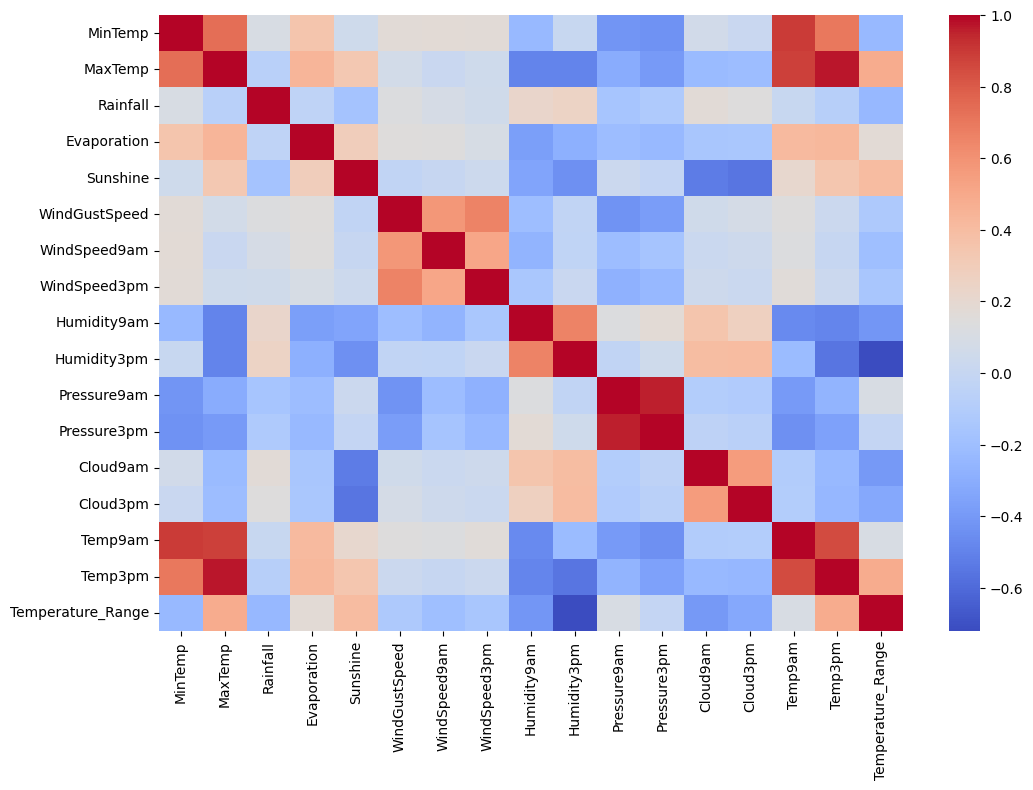

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
corr,
cmap="coolwarm"
)

plt.show()

Visually confirms the correlation patterns — strong clustering among temperature/pressure variables, weaker/negative relationships involving rainfall and sunshine.

In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df[["MaxTemp","MinTemp","Rainfall"]] = scaler.fit_transform(
df[["MaxTemp","MinTemp","Rainfall"]]
)

df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,Temperature_Range
0,2008-12-01,Albury,0.516509,0.523629,0.001617,5.468232,7.611178,W,44.0,W,...,22.0,1007.7,1007.1,8.000000,4.50993,16.9,21.8,No,No,9.5
1,2008-12-02,Albury,0.375000,0.565217,0.000000,5.468232,7.611178,WNW,44.0,NNW,...,25.0,1010.6,1007.8,4.447461,4.50993,17.2,24.3,No,No,17.7
2,2008-12-03,Albury,0.504717,0.576560,0.000000,5.468232,7.611178,WSW,46.0,W,...,30.0,1007.6,1008.7,4.447461,2.00000,21.0,23.2,No,No,12.8
3,2008-12-04,Albury,0.417453,0.620038,0.000000,5.468232,7.611178,NE,24.0,SE,...,16.0,1017.6,1012.8,4.447461,4.50993,18.1,26.5,No,No,18.8
4,2008-12-05,Albury,0.613208,0.701323,0.002695,5.468232,7.611178,W,41.0,ENE,...,33.0,1010.8,1006.0,7.000000,8.00000,17.8,29.7,No,No,14.8


Values successfully rescaled to 0–1 range — necessary step before feeding into distance-based or gradient-based ML models.

In [ ]:
df1 = df[["Location","MaxTemp"]].head(10)

df2 = df[["Location","Rainfall"]].head(10)

In [ ]:
merged_df = pd.merge(
df1,
df2,
on="Location"
)

merged_df

,Location,MaxTemp,Rainfall
0,Albury,0.523629,0.001617
1,Albury,0.523629,0.000000
2,Albury,0.523629,0.000000
3,Albury,0.523629,0.000000
4,Albury,0.523629,0.002695
...,...,...,...
95,Albury,0.659735,0.000539
96,Albury,0.659735,0.000000
97,Albury,0.659735,0.000000
98,Albury,0.659735,0.000000


Since "Albury" repeats across all 10 rows in both frames, the merge performs a many-to-many join, producing 100 rows (10×10) instead of 10 a common pandas pitfall when merging on a non-unique key.

In [ ]:
concat_df = pd.concat(
[df1,df2],
axis=1
)

concat_df

,Location,MaxTemp,Location,Rainfall
0,Albury,0.523629,Albury,0.001617
1,Albury,0.565217,Albury,0.000000
2,Albury,0.576560,Albury,0.000000
3,Albury,0.620038,Albury,0.000000
4,Albury,0.701323,Albury,0.002695
5,Albury,0.652174,Albury,0.000539
6,Albury,0.563327,Albury,0.000000
7,Albury,0.595463,Albury,0.000000
8,Albury,0.693762,Albury,0.000000
9,Albury,0.659735,Albury,0.003774


Correctly aligns the two frames side-by-side by index, preserving the original 10 rows shows the difference between merge (key-based join) and concat (positional combination).